# 04 — Condition A: LLM-Only Baseline

**Project:** DDI-Graph-LLM  
**Phase 4:** Test an LLM (GPT-4o-mini) with only drug names — no graph features. This is the pure LLM baseline (Condition A).

**Input:** `../data/edge_features.csv` (from Phase 2)  
**Evaluation metric:** Macro-F1 on the same 1,000-sample test subset used across all conditions  
**Model:** GPT-4o-mini via OpenAI API


In [1]:
import pandas as pd
import numpy as np
import os
import time
import json
from collections import Counter
from openai import OpenAI
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 1. API Key Setup


In [ ]:
api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Set OPENAI_API_KEY environment variable first!")


OpenAI client initialized.


## 2. Sample Test Subset

We sample 1,000 edges from the test set (stratified by label) for LLM evaluation. This same subset will be reused for Conditions B1, B2, and C to ensure fair comparison.


In [3]:
df = pd.read_csv("../data/edge_features.csv")

FEATURE_COLS = [
    "out_degree_u", "in_degree_u", "betweenness_u", "clustering_u", "pagerank_u",
    "out_degree_v", "in_degree_v", "betweenness_v", "clustering_v", "pagerank_v",
    "common_neighbors", "jaccard", "same_community", "degree_diff",
]

X = df[FEATURE_COLS].values
y = df["label"].values

# Same split as Phase 3
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# Get the test set rows from original df
df_test = df.loc[idx_test].copy()
print(f"Full test set: {len(df_test):,}")

# Stratified sample of ~1000 using sklearn
from sklearn.model_selection import train_test_split as stratified_split

_, df_sample = stratified_split(
    df_test, test_size=1000, random_state=42, stratify=df_test['label']
)
df_sample = df_sample.reset_index(drop=True)

print(f"Sampled test subset: {len(df_sample):,}")
print(f"\nSample label distribution:")
print(df_sample['label'].value_counts().to_string())

# Save sample for reuse across conditions
df_sample.to_csv("../data/test_sample_1000.csv", index=False)
print(f"\nSaved test_sample_1000.csv")

Full test set: 38,251
Sampled test subset: 1,000

Sample label distribution:
label
adverse_effects    321
activity           237
metabolism         209
concentration      176
efficacy            42
excretion           10
absorption           5

Saved test_sample_1000.csv


## 3. Re-evaluate Random Forest on Same Subset

For fair comparison, compute RF's macro-F1 on the exact same 1,000 samples.


In [4]:
from sklearn.ensemble import RandomForestClassifier

# Retrain RF (same params as Phase 3)
clf = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=42,
    class_weight="balanced", n_jobs=-1
)
clf.fit(X_train, y_train)

# Predict on the 1000-sample subset
X_sample = df_sample[FEATURE_COLS].values
y_sample_true = df_sample['label'].values
y_sample_rf = clf.predict(X_sample)

rf_f1 = f1_score(y_sample_true, y_sample_rf, average="macro")
print(f"RF Macro-F1 on 1000-sample subset: {rf_f1:.4f}")


RF Macro-F1 on 1000-sample subset: 0.9268


## 4. LLM-Only Prediction (Condition A)

For each drug pair, we prompt GPT-4o-mini with **only the drug names** — no graph features, no interaction description. The LLM must rely entirely on its pretrained biomedical knowledge.


In [5]:
VALID_LABELS = {"metabolism", "concentration", "adverse_effects", "absorption", "activity", "efficacy", "excretion"}

def predict_llm_only(drug_u: str, drug_v: str, client, model="gpt-4o-mini") -> str:
    """
    Condition A: Prompt LLM with drug names only.
    Returns predicted interaction type label.
    """
    prompt = f"""You are a pharmacology expert. Given a pair of drugs that are known to interact,
predict the type of drug-drug interaction.

The possible interaction types are:
1. metabolism — one drug affects the metabolism (breakdown) of the other
2. concentration — one drug changes the serum concentration of the other
3. adverse_effects — the combination increases the risk or severity of side effects
4. absorption — one drug affects the absorption of the other
5. activity — one drug increases or decreases a specific pharmacological activity of the other
6. efficacy — one drug changes the therapeutic efficacy of the other
7. excretion — one drug affects the excretion rate of the other

Drug pair: {drug_u} → {drug_v}
(This means {drug_u} has a documented effect on {drug_v}.)

Respond with ONLY one of these labels: metabolism, concentration, adverse_effects, absorption, activity, efficacy, excretion
Your prediction:"""

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=20,
            temperature=0,
        )
        pred = response.choices[0].message.content.strip().lower()
        # Clean up common variations
        pred = pred.replace(" ", "_").replace("-", "_")
        if pred in VALID_LABELS:
            return pred
        # Try partial match
        for label in VALID_LABELS:
            if label in pred:
                return label
        return pred  # Return raw if no match (will count as wrong)
    except Exception as e:
        print(f"  Error for {drug_u} → {drug_v}: {e}")
        return "error"


## 5. Run LLM Predictions

In [6]:
predictions = []
t0 = time.time()

for i, (_, row) in enumerate(df_sample.iterrows()):
    pred = predict_llm_only(row['drug_u'], row['drug_v'], client)
    predictions.append(pred)
    
    if (i + 1) % 100 == 0:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (len(df_sample) - i - 1) / rate
        print(f"  [{i+1:>4}/{len(df_sample)}]  {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining, rate={rate:.1f}/s")

elapsed = time.time() - t0
print(f"\nDone: {len(predictions)} predictions in {elapsed:.0f}s ({len(predictions)/elapsed:.1f}/s)")

df_sample['pred_llm'] = predictions


  [ 100/1000]  57s elapsed, ~509s remaining, rate=1.8/s
  [ 200/1000]  142s elapsed, ~567s remaining, rate=1.4/s
  [ 300/1000]  191s elapsed, ~445s remaining, rate=1.6/s
  [ 400/1000]  244s elapsed, ~365s remaining, rate=1.6/s
  [ 500/1000]  305s elapsed, ~305s remaining, rate=1.6/s
  [ 600/1000]  388s elapsed, ~259s remaining, rate=1.5/s
  [ 700/1000]  443s elapsed, ~190s remaining, rate=1.6/s
  [ 800/1000]  506s elapsed, ~127s remaining, rate=1.6/s
  [ 900/1000]  561s elapsed, ~62s remaining, rate=1.6/s
  [1000/1000]  615s elapsed, ~0s remaining, rate=1.6/s

Done: 1000 predictions in 615s (1.6/s)


## 6. Clean and Evaluate Predictions

In [7]:
# Check for any invalid predictions
valid_mask = df_sample['pred_llm'].isin(VALID_LABELS)
n_valid = valid_mask.sum()
n_invalid = (~valid_mask).sum()

print(f"Valid predictions: {n_valid} ({n_valid/len(df_sample):.1%})")
print(f"Invalid predictions: {n_invalid}")

if n_invalid > 0:
    print(f"\nInvalid prediction values:")
    print(df_sample.loc[~valid_mask, 'pred_llm'].value_counts().to_string())

# Compute metrics on valid predictions only
df_eval = df_sample[valid_mask].copy()
y_true = df_eval['label'].values
y_pred_llm = df_eval['pred_llm'].values

llm_f1 = f1_score(y_true, y_pred_llm, average="macro")
llm_acc = np.mean(y_true == y_pred_llm)

print(f"\n{'='*50}")
print(f"CONDITION A: LLM-ONLY RESULTS")
print(f"{'='*50}")
print(f"Evaluated on: {len(df_eval)} valid predictions")
print(f"Accuracy:     {llm_acc:.4f}")
print(f"Macro-F1:     {llm_f1:.4f}")
print(f"Random baseline: {1/7:.4f}")
print(f"Ratio over random: {llm_f1/(1/7):.1f}x")


Valid predictions: 1000 (100.0%)
Invalid predictions: 0

CONDITION A: LLM-ONLY RESULTS
Evaluated on: 1000 valid predictions
Accuracy:     0.3320
Macro-F1:     0.2185
Random baseline: 0.1429
Ratio over random: 1.5x


### 6.1 Per-Class Report

In [8]:
print(classification_report(y_true, y_pred_llm))


                 precision    recall  f1-score   support

     absorption       0.12      0.60      0.20         5
       activity       0.40      0.35      0.37       237
adverse_effects       0.62      0.17      0.26       321
  concentration       0.20      0.01      0.01       176
       efficacy       0.00      0.00      0.00        42
      excretion       0.33      0.20      0.25        10
     metabolism       0.28      0.90      0.43       209

       accuracy                           0.33      1000
      macro avg       0.28      0.32      0.22      1000
   weighted avg       0.39      0.33      0.27      1000



C:\Users\weddi\AppData\Roaming\uv\python\cpython-3.14.2-windows-x86_64-none\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\weddi\AppData\Roaming\uv\python\cpython-3.14.2-windows-x86_64-none\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\weddi\AppData\Roaming\uv\python\cpython-3.14.2-windows-x86_64-none\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

### 6.2 Confusion Matrix

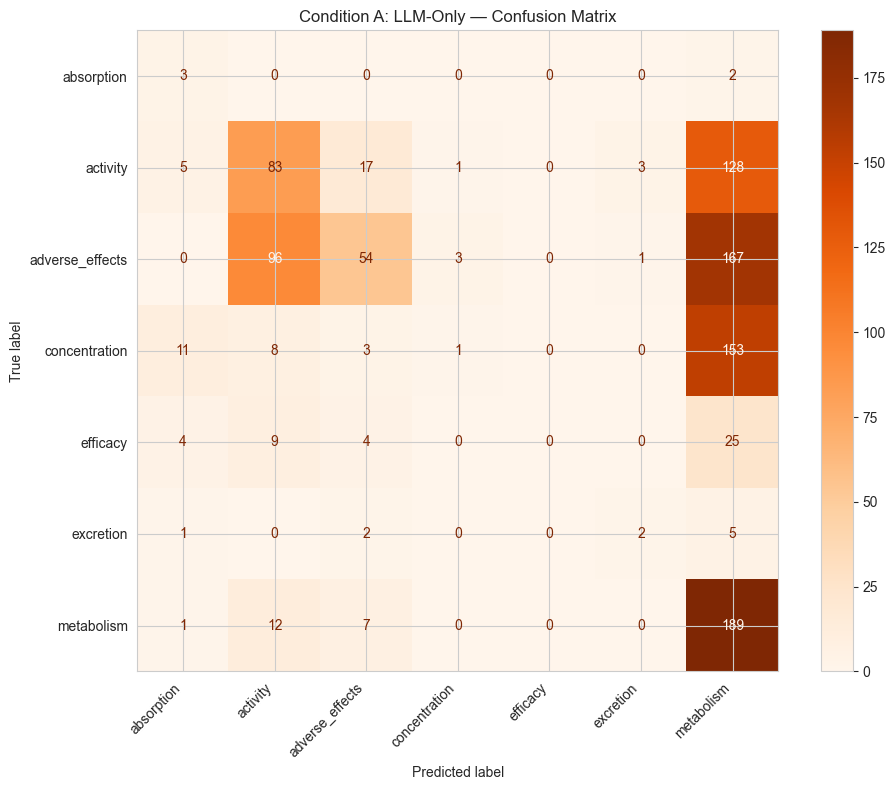

In [9]:
labels = sorted(VALID_LABELS)

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_llm, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Condition A: LLM-Only — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. Head-to-Head: RF vs LLM (on same 1000 samples)

In [10]:
# RF on the same valid subset
y_rf_subset = clf.predict(df_eval[FEATURE_COLS].values)
rf_f1_subset = f1_score(y_true, y_rf_subset, average="macro")

print("=" * 50)
print("COMPARISON ON SAME TEST SUBSET")
print("=" * 50)
print(f"{'Condition':<25} {'Macro-F1':>10}")
print("-" * 37)
print(f"{'Random baseline (1/7)':<25} {1/7:>10.4f}")
print(f"{'A: LLM-only':<25} {llm_f1:>10.4f}")
print(f"{'B1: Random Forest':<25} {rf_f1_subset:>10.4f}")
print("-" * 37)
print(f"{'RF advantage over LLM':<25} {rf_f1_subset - llm_f1:>+10.4f}")


COMPARISON ON SAME TEST SUBSET
Condition                   Macro-F1
-------------------------------------
Random baseline (1/7)         0.1429
A: LLM-only                   0.2185
B1: Random Forest             0.9268
-------------------------------------
RF advantage over LLM        +0.7083


### 7.1 Prediction Distribution Comparison

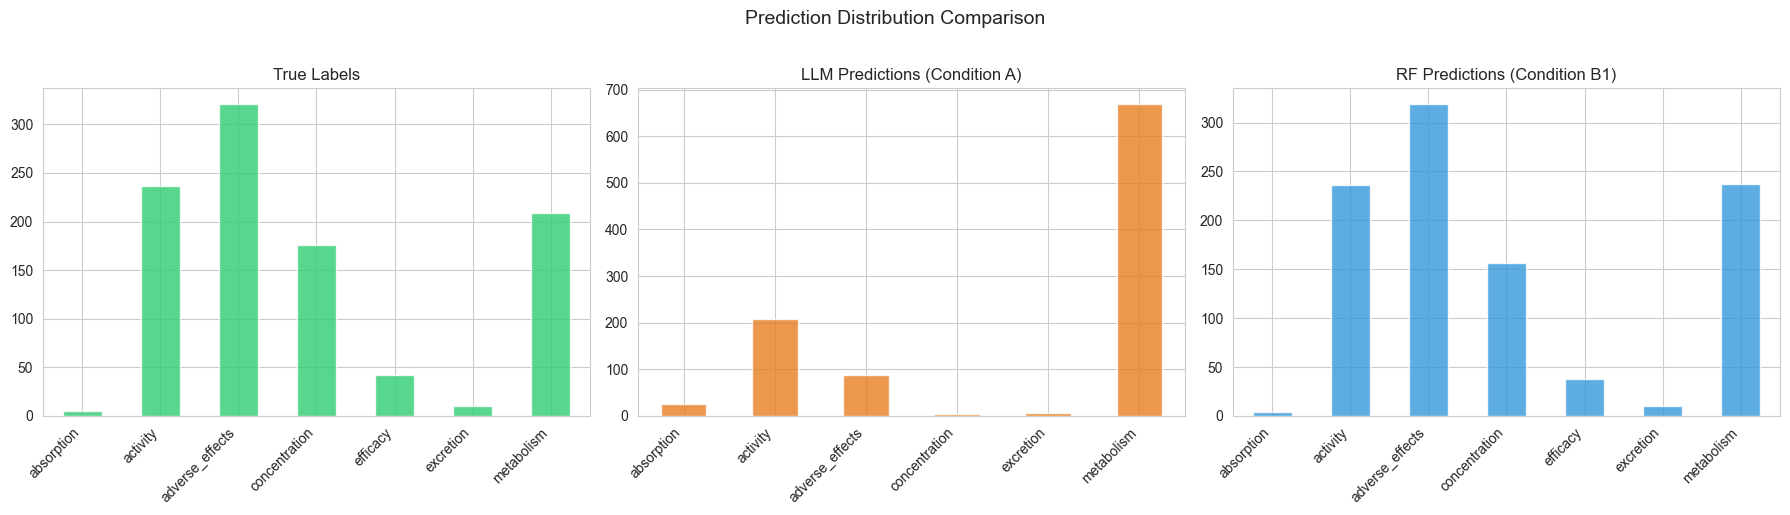

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True distribution
true_counts = pd.Series(y_true).value_counts().sort_index()
true_counts.plot(kind='bar', ax=axes[0], color='#2ecc71', alpha=0.8)
axes[0].set_title('True Labels')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# LLM predictions
llm_counts = pd.Series(y_pred_llm).value_counts().sort_index()
llm_counts.plot(kind='bar', ax=axes[1], color='#e67e22', alpha=0.8)
axes[1].set_title('LLM Predictions (Condition A)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# RF predictions
rf_counts = pd.Series(y_rf_subset).value_counts().sort_index()
rf_counts.plot(kind='bar', ax=axes[2], color='#3498db', alpha=0.8)
axes[2].set_title('RF Predictions (Condition B1)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Prediction Distribution Comparison', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 8. Save Results

In [12]:
df_sample.to_csv("../data/results_condition_a.csv", index=False)
print(f"Saved results_condition_a.csv: {len(df_sample):,} rows")
print(f"\nFinal score — Condition A (LLM-only): Macro-F1 = {llm_f1:.4f}")


Saved results_condition_a.csv: 1,000 rows

Final score — Condition A (LLM-only): Macro-F1 = 0.2185


## Summary

**Condition A (LLM-only) complete.**

| Condition | Macro-F1 |
|-----------|----------|
| Random baseline (1/7) | 0.1429 |
| **A: LLM-only** | **TBD (run notebook)** |
| B1: Random Forest | TBD (on same subset) |

**Key question for next phases:**  
Can the LangGraph agent (Condition C), which combines LLM reasoning WITH graph features, outperform both A and B1?

**Next:** 
- Phase 5 — Condition B2 (GNN) in `05_gnn.ipynb`
- Phase 6 — Condition C (LangGraph agent) in `06_langgraph_agent.ipynb`
